(monoblock)=
# Monoblock

In this task, we will learn how to run CAD-based simulations.

Our example case will be a 3D ITER-like monoblock made of three different materials (tungsten, cucrzr, and copper).

## Mesh

```{seealso}
[](meshes) for more details on meshing in FESTIM
```

In [1]:
import meshio


def convert_med_to_xdmf(
    med_file,
    cell_file="mesh_domains.xdmf",
    facet_file="mesh_boundaries.xdmf",
    cell_type="tetra",
    facet_type="triangle",
):
    """Converts a MED mesh to XDMF
    Args:
        med_file (str): the name of the MED file
        cell_file (str, optional): the name of the file containing the
            volume markers. Defaults to "mesh_domains.xdmf".
        facet_file (str, optional): the name of the file containing the
            surface markers.. Defaults to "mesh_boundaries.xdmf".
        cell_type (str, optional): The topology of the cells. Defaults to "tetra".
        facet_type (str, optional): The topology of the facets. Defaults to "triangle".
    Returns:
        dict, dict: the correspondance dict, the cell types
    """
    msh = meshio.read(med_file)

    correspondance_dict = {-k: v for k, v in msh.cell_tags.items()}
    
    cell_data_types = msh.cell_data_dict["cell_tags"].keys()

    for mesh_block in msh.cells:
        if mesh_block.type == cell_type:
            meshio.write_points_cells(
                cell_file,
                msh.points,
                [mesh_block],
                cell_data={"f": [-1 * msh.cell_data_dict["cell_tags"][cell_type]]},
            )
        elif mesh_block.type == facet_type:
            meshio.write_points_cells(
                facet_file,
                msh.points,
                [mesh_block],
                cell_data={"f": [-1 * msh.cell_data_dict["cell_tags"][facet_type]]},
            )

    return correspondance_dict, cell_data_types

In [2]:
correspondance_dict, cell_data_types = convert_med_to_xdmf(
    "task08/mesh.med",
    cell_file="task08/mesh_domains.xdmf",
    facet_file="task08/mesh_boundaries.xdmf",
)

for index, label in correspondance_dict.items():
    print(f"{index}: {label[0]}")

6: tungsten
7: copper
8: cucrzr
9: top_surface
10: coolant_surface
11: poloidal_tungsten
12: poloidal_copper
13: poloidal_cucrzr
14: toroidal
15: bottom
16: interface_tungsten_copper
17: interface_copper_cucrzr


The converted .xdmf files can then be imported in FESTIM using the `MeshFromXDMF` class:

In [3]:
import festim as F

mesh = F.MeshFromXDMF(
    volume_file="task08/mesh_domains.xdmf", facet_file="task08/mesh_boundaries.xdmf"
)

mesh.mesh.geometry.x[:] *= 1e-3  # mm to m

# rotate to have z as the vertical axis
mesh.mesh.geometry.x[:, [0, 1, 2]] = mesh.mesh.geometry.x[:, [0, 2, 1]]

/home/remidm/miniconda3/envs/festim-workshop/lib/python3.13/site-packages/festim/coupled_heat_hydrogen_problem.py:1: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  import tqdm.autonotebook


In [4]:
from dolfinx import plot
import pyvista

ct = mesh.define_volume_meshtags()
ft = mesh.define_surface_meshtags()
fdim = mesh.mesh.topology.dim - 1
tdim = mesh.mesh.topology.dim

pyvista.set_jupyter_backend("html")

p = pyvista.Plotter(shape=(1, 3))
p.subplot(0, 0)

topology, cell_types, geometry = plot.vtk_mesh(mesh.mesh, tdim)
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

p.add_mesh(grid, show_edges=True)
p.camera.zoom("tight")

p.view_vector((1, 1, 1))


p.subplot(0, 1)


mesh.mesh.topology.create_connectivity(fdim, tdim)
topology, cell_types, x = plot.vtk_mesh(
    mesh.mesh, tdim, ct.indices
)

grid = pyvista.UnstructuredGrid(topology, cell_types, x)
grid.cell_data["Cell Marker"] = ct.values
grid.set_active_scalars("Cell Marker")
p.add_mesh(grid, show_edges=False)
p.view_vector((1, 1, 1))


p.subplot(0, 2)

topology, cell_types, x = plot.vtk_mesh(
    mesh.mesh, fdim, ft.indices
)

grid = pyvista.UnstructuredGrid(topology, cell_types, x)
grid.cell_data["Facet Marker"] = ft.values
grid.set_active_scalars("Facet Marker")
p.add_mesh(grid, show_edges=False)
p.view_vector((1, 1, 1))

p.link_views()
p.show_axes_all()
if pyvista.OFF_SCREEN:
    figure = p.screenshot("mb_mesh.png")
p.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

# Subdomains and materials

We start by defining three materials for tungsten, copper, and CuCrZr

In [5]:
tungsten = F.Material(
    D_0=4.1e-7,
    E_D=0.39,
    K_S_0=1.87e24,
    E_K_S=1.04,
    thermal_conductivity=100,
)

copper = F.Material(
    D_0=6.6e-7,
    E_D=0.387,
    K_S_0=3.14e24,
    E_K_S=0.572,
    thermal_conductivity=350,
)

cucrzr = F.Material(
    D_0=3.92e-7,
    E_D=0.418,
    K_S_0=4.28e23,
    E_K_S=0.387,
    thermal_conductivity=350,
)

Using the tags provided by `correspondance_dict`, we can create volume and surface subdomains and assign them materials:

In [6]:
tungsten_volume = F.VolumeSubdomain(id=6, material=tungsten)
copper_volume = F.VolumeSubdomain(id=7, material=copper)
cucrzr_volume = F.VolumeSubdomain(id=8, material=cucrzr)

top_surface = F.SurfaceSubdomain(id=9)
cooling_surface = F.SurfaceSubdomain(id=10)
poloidal_gap_w = F.SurfaceSubdomain(id=11)
poloidal_gap_cu = F.SurfaceSubdomain(id=12)
poloidal_gap_cucrzr = F.SurfaceSubdomain(id=13)
toroidal_gap = F.SurfaceSubdomain(id=14)
bottom = F.SurfaceSubdomain(id=15)

all_subdomains = [
    tungsten_volume,
    copper_volume,
    cucrzr_volume,
    top_surface,
    cooling_surface,
    poloidal_gap_cu,
    poloidal_gap_w,
    poloidal_gap_cucrzr,
    toroidal_gap,
    bottom,
]

## Solving the heat transfer problem

In [7]:
heat_transfer_problem = F.HeatTransferProblem()

# Mesh and subdomains
heat_transfer_problem.subdomains = all_subdomains
heat_transfer_problem.mesh = mesh

# Boundary conditions
heat_flux_top = F.HeatFluxBC(subdomain=top_surface, value=10e6)
convective_flux_coolant = F.HeatFluxBC(
    subdomain=cooling_surface, value=lambda T: 7e04 * (323 - T)
)

heat_transfer_problem.boundary_conditions = [heat_flux_top, convective_flux_coolant]

# Exports
heat_transfer_problem.exports = [F.VTXTemperatureExport("out.bp")]

# Settings
heat_transfer_problem.settings = F.Settings(
    atol=1e-10,
    rtol=1e-10,
    transient=False,
)

# Run
heat_transfer_problem.initialise()
heat_transfer_problem.run()

In [8]:
from dolfinx import plot

T = heat_transfer_problem.u

topology, cell_types, geometry = plot.vtk_mesh(T.function_space)
u_grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
u_grid.point_data["T"] = T.x.array.real
u_grid.set_active_scalars("T")
u_plotter = pyvista.Plotter()
u_plotter.add_mesh(u_grid, cmap="inferno", show_edges=False)
# u_plotter.add_mesh(u_grid, style="wireframe", color="white", opacity=0.2)

contours = u_grid.contour(9)
u_plotter.add_mesh(contours, color="white")

u_plotter.view_vector((1, 1, 1))

if not pyvista.OFF_SCREEN:
    u_plotter.show()
else:
    figure = u_plotter.screenshot("temperature.png")

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

## Solving the tritium transport problem

In [9]:
my_model = F.HydrogenTransportProblemDiscontinuous()
my_model.method_interface = "penalty"

my_model.subdomains = all_subdomains

H = F.Species("H", subdomains=my_model.volume_subdomains)
my_model.species = [H]

my_model.mesh = mesh

my_model.surface_to_volume = {
    top_surface: tungsten_volume,
    cooling_surface: cucrzr_volume,
    poloidal_gap_w: tungsten_volume,
    poloidal_gap_cu: copper_volume,
    poloidal_gap_cucrzr: cucrzr_volume,
    toroidal_gap: tungsten_volume,
    bottom: tungsten_volume,
}

penalty_term = 1e20
my_model.interfaces = [
    F.Interface(
        id=16, subdomains=(tungsten_volume, copper_volume), penalty_term=penalty_term
    ),
    F.Interface(
        id=17, subdomains=(copper_volume, cucrzr_volume), penalty_term=penalty_term
    ),
]

Similarily, the surface subdomains are used to create boundary conditions:

In [10]:
import ufl

# Plasma implantation flux BC
phi = 1.61e22
R_p = 9.52e-10
implantation_flux_top = F.FixedConcentrationBC(
    subdomain=top_surface,
    value=lambda T: phi * R_p / (tungsten.D_0 * ufl.exp(-tungsten.E_D / F.k_B / T)),
    species=H,
)

# Instantaneous molecular recombination flux BCs at all other surfaces (fixed concentration of 0)
recombination_fluxes = [
    F.FixedConcentrationBC(subdomain=surf, value=0, species=H)
    for surf in [
        toroidal_gap,
        bottom,
        poloidal_gap_w,
        poloidal_gap_cu,
        poloidal_gap_cucrzr,
        cooling_surface,
    ]
]

my_model.boundary_conditions = [implantation_flux_top] + recombination_fluxes

To use the temperature from the heat transfer problem, we simply set:

In [11]:
my_model.temperature = heat_transfer_problem.u

We define some derived quantities exports:

In [ ]:
exports = {
    "poloidal_gap_cu_flux": F.SurfaceFlux(surface=poloidal_gap_cu, field=H),
    "poloidal_gap_cucrzr_flux": F.SurfaceFlux(surface=poloidal_gap_cucrzr, field=H),
    "poloidal_gap_w_flux": F.SurfaceFlux(surface=poloidal_gap_w, field=H),
    "toroidal_gap_flux": F.SurfaceFlux(surface=toroidal_gap, field=H),
    "bottom_flux": F.SurfaceFlux(surface=bottom, field=H),
    "inventory_w": F.TotalVolume(field=H, volume=tungsten_volume),
    "inventory_cu": F.TotalVolume(field=H, volume=copper_volume),
    "inventory_cucrzr": F.TotalVolume(field=H, volume=cucrzr_volume),
}


my_model.exports = list(exports.values())

```{seealso}
[](derived_quantities) for more information on these exports.
```

In [22]:
my_model.settings = F.Settings(
    atol=1e-8,
    rtol=1e-10,
    transient=False,
    max_iterations=10,
)

my_model.initialise()
my_model.run()

Computing total volume of H in volume subdomain 6 with function H_6
Computing total volume of H in volume subdomain 7 with function H_7
Computing total volume of H in volume subdomain 8 with function H_8


In [23]:
# some checks
assert my_model.interfaces[0].id in tungsten_volume.ft.values
assert my_model.interfaces[0].id in copper_volume.ft.values
assert my_model.interfaces[1].id in copper_volume.ft.values
assert my_model.interfaces[1].id in cucrzr_volume.ft.values

### Post processing

In [24]:
p = pyvista.Plotter(shape=(1, 2))
p.subplot(0, 0)

for vol in my_model.volume_subdomains:
    sol = H.subdomain_to_post_processing_solution[vol]

    topology, cell_types, geometry = plot.vtk_mesh(sol.function_space)
    u_grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
    u_grid.point_data["c"] = sol.x.array.real
    u_grid.set_active_scalars("c")
    p.add_mesh(u_grid, cmap="viridis", show_edges=False)

p.view_vector((0.5, -0.4, 0.3))


p.subplot(0, 1)
topology, cell_types, geometry = plot.vtk_mesh(heat_transfer_problem.u.function_space)
u_grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
u_grid.point_data["T"] = heat_transfer_problem.u.x.array.real
u_grid.set_active_scalars("T")
p.add_mesh(u_grid, cmap="inferno", show_edges=False)
p.view_vector((0.5, -0.4, 0.3))

p.link_views()
p.show_axes_all()

if not pyvista.OFF_SCREEN:
    p.show()
else:
    figure = p.screenshot("concentration.png")

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

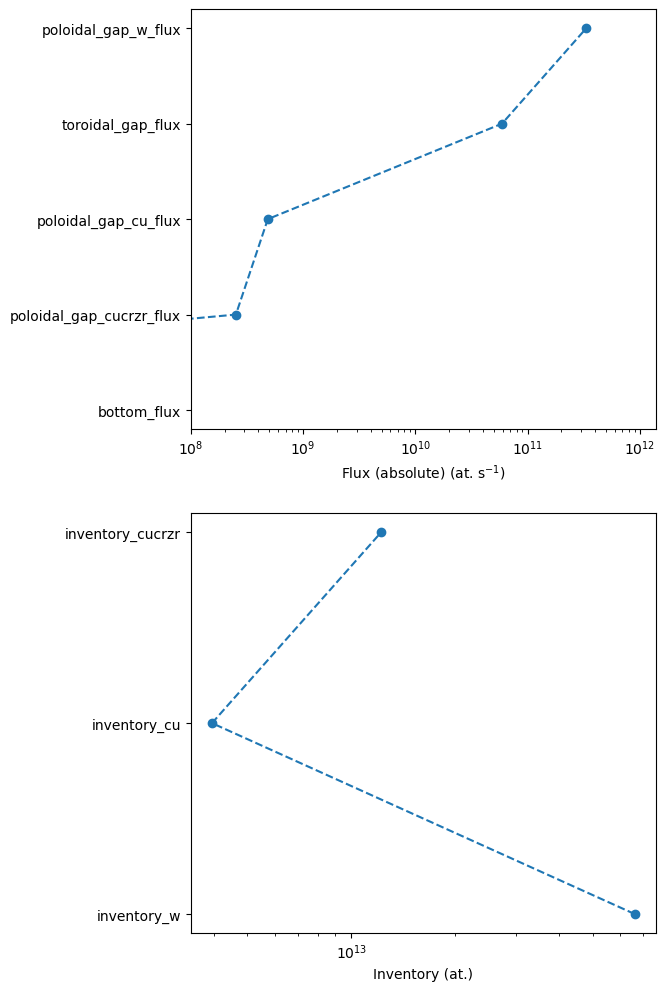

In [25]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(6, 12))

plt.sca(axs[0])
all_fluxes_vals = [np.abs(flux.data[0]) for flux in exports.values() if isinstance(flux, F.SurfaceFlux)]
all_fluxes_labels = [name for name, flux in exports.items() if isinstance(flux, F.SurfaceFlux)]

# sort
all_fluxes_vals, all_fluxes_labels = zip(*sorted(zip(all_fluxes_vals, all_fluxes_labels)))

plt.plot(all_fluxes_vals, all_fluxes_labels, marker="o", linestyle="--")
plt.xlabel("Flux (absolute) (at. s$^{-1}$)")
plt.xscale("log")
plt.xlim(left=1e8)

plt.sca(axs[1])
all_inventories_vals = [inv.data[0] for inv in exports.values() if isinstance(inv, F.TotalVolume)]
all_inventories_labels = [name for name, inv in exports.items() if isinstance(inv, F.TotalVolume)]
plt.plot(all_inventories_vals, all_inventories_labels, marker="o", linestyle="--")
plt.xlabel("Inventory (at.)")
plt.xscale("log")
plt.show()